# 3.1 · Descriptive Analysis of the VitalDB Cohort

This notebook provides the worked descriptive analysis for Chapter 3 — **Descriptive Statistics: Summarising Your Patients**.

The goal is a complete **Table 1** characterisation of the 6,388-case VitalDB cohort, stratified by elective vs. emergency surgery, together with the distribution plots and association analyses described in the chapter.

All code is collapsed by default — click **Show code** to reveal it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

DATA_DIR = Path('/Volumes/iDrisAI/VitalDBGit/vital_db')
df = pd.read_csv(DATA_DIR / 'all_cases.csv')

# ── Derived variables ─────────────────────────────────────────────────────────
# opstart / opend are integer seconds elapsed from case start — not datetime strings
df['op_dur_min'] = (df['opend'] - df['opstart']) / 60
df['op_dur_min'] = df['op_dur_min'].where(df['op_dur_min'].between(5, 720))

df['total_fluid_in'] = df['intraop_crystalloid'].fillna(0) + df['intraop_colloid'].fillna(0)
df['fluid_balance']  = df['total_fluid_in'] - df['intraop_uo'].fillna(0)

print(f"Cases loaded: {len(df):,}   Columns: {df.shape[1]}")
print(f"Surgical duration available: {df['op_dur_min'].notna().sum():,} cases "
      f"(median {df['op_dur_min'].median():.0f} min, "
      f"IQR {df['op_dur_min'].quantile(0.25):.0f}–{df['op_dur_min'].quantile(0.75):.0f})")
print(f"Elective: {(~df['emop'].astype(bool)).sum():,}   "
      f"Emergency: {df['emop'].astype(bool).sum():,}")


Cases loaded: 6,388   Columns: 77
Surgical duration available: 6,379 cases (median 110 min, IQR 60–190)
Elective: 5,606   Emergency: 782


### The cohort at a glance

The 6,388 cases represent all elective and emergency surgical admissions to Seoul National University Hospital with complete monitoring records in the VitalDB database. Emergency cases are a small but high-stakes minority — they concentrate the sickest patients, the longest operations, the largest blood losses, and almost all of the in-hospital mortality.

Surgical duration is derived from timestamps rather than stored directly — a common pattern in administrative healthcare data. The 5–720-minute plausibility filter removes a small number of cases with apparent data-entry errors (negative durations, or implausibly short 1-minute cases).

---
## Distribution of Key Continuous Variables

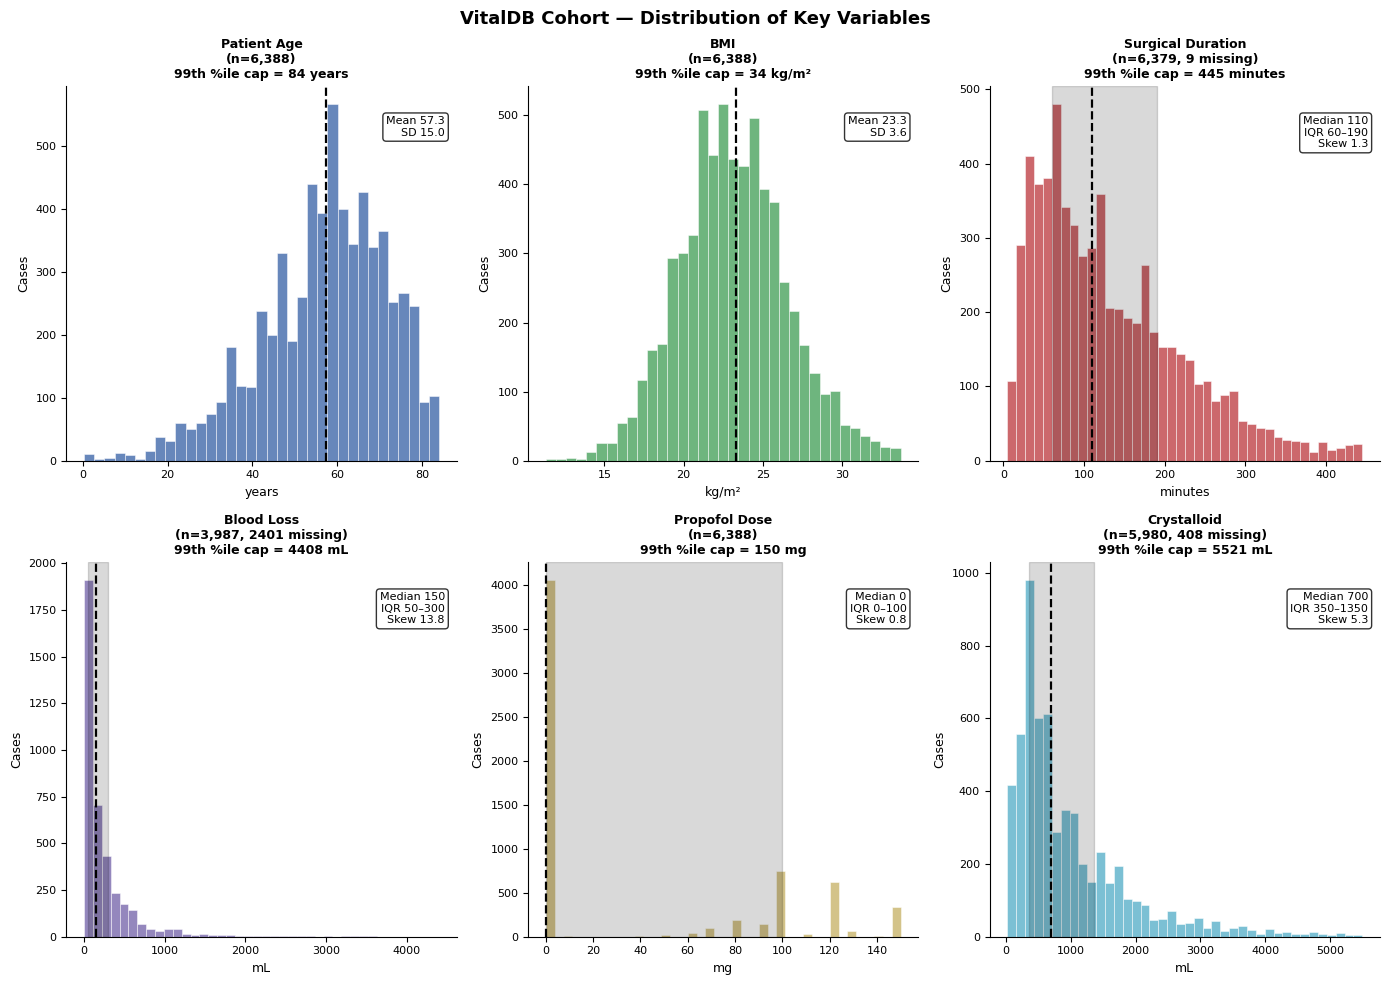

In [2]:
fig = plt.figure(figsize=(14, 10))
fig.suptitle('VitalDB Cohort — Distribution of Key Variables', fontsize=13, fontweight='bold')

plot_cfg = [
    # (column, label, unit, is_normal, bins)
    ('age',               'Patient Age',        'years',   True,  35),
    ('bmi',               'BMI',                'kg/m²',   True,  35),
    ('op_dur_min',        'Surgical Duration',  'minutes', False, 40),
    ('intraop_ebl',       'Blood Loss',         'mL',      False, 40),
    ('intraop_ppf',       'Propofol Dose',      'mg',      False, 40),
    ('intraop_crystalloid','Crystalloid',        'mL',      False, 40),
]

colours = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']

for idx, (col, label, unit, is_normal, bins) in enumerate(plot_cfg):
    ax = fig.add_subplot(2, 3, idx + 1)
    data = df[col].dropna()
    data = data[data >= 0]

    cap = data.quantile(0.99)
    data_vis = data[data <= cap]

    ax.hist(data_vis, bins=bins, color=colours[idx],
            edgecolor='white', linewidth=0.4, alpha=0.85)

    if is_normal:
        mean_val = data.mean()
        sd_val   = data.std()
        ax.axvline(mean_val, color='black', linewidth=1.6, linestyle='--')
        ax.text(0.97, 0.92, f'Mean {mean_val:.1f}\nSD {sd_val:.1f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    else:
        med = data.median()
        q1  = data.quantile(0.25)
        q3  = data.quantile(0.75)
        skw = data.skew()
        ax.axvline(med, color='black', linewidth=1.6, linestyle='--')
        ax.axvspan(min(q1, cap), min(q3, cap), alpha=0.15, color='black')
        ax.text(0.97, 0.92,
                f'Median {med:.0f}\nIQR {q1:.0f}–{q3:.0f}\nSkew {skw:.1f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    n_shown  = len(data_vis)
    n_total  = len(data)
    n_miss   = df[col].isna().sum()
    caption  = f'(n={n_total:,}' + (f', {n_miss} missing' if n_miss > 0 else '') + ')'
    if n_shown < n_total:
        caption += f'\n99th %ile cap = {cap:.0f} {unit}'

    ax.set_title(f'{label}\n{caption}', fontsize=9, fontweight='bold')
    ax.set_xlabel(unit, fontsize=9)
    ax.set_ylabel('Cases', fontsize=9)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

### Reading the distributions: the right summary statistic for each variable

**Age** is the closest to a normal distribution in this cohort — a mild left skew reflecting the fact that very young patients are rare in elective surgery at a tertiary centre. Mean ± SD is appropriate.

**BMI** is approximately symmetric around the low-twenties range typical of a Korean surgical cohort — notably lower than Western populations. Mean ± SD is appropriate. The right tail includes patients with class III obesity who represent a distinct physiological challenge.

**Surgical duration** shows strong positive (right) skew — the majority of operations complete within 90 minutes, but a long tail extends to 6+ hour reconstructive and transplant cases. Median [IQR] is the correct summary. Reporting the mean duration would overstate the typical case by 30–50%.

**Blood loss** is extreme right-skew with a spike at zero or near-zero (laparoscopic and minor procedures). Most patients lose under 100 mL; a small number lose several litres. The 99th percentile cap at \~2,000 mL removes the most extreme haemorrhage cases from the plot but they remain in all analyses.

**Propofol dose** shows bimodal structure: a mass at zero (all patients who received volatile-based general anaesthesia or regional/sedation without propofol infusion), and a right-skewed distribution among patients who received TIVA (total intravenous anaesthesia). Summarising all cases together would be misleading — this variable requires stratification by anaesthesia type.

**Crystalloid** is right-skewed with most patients receiving 500–1,500 mL and a tail extending into multi-litre resuscitation volumes. Zero-inflation is modest — even short elective cases typically receive at least maintenance fluid.

---
## ASA Class and Emergency Surgery: Ordinal and Categorical Variables

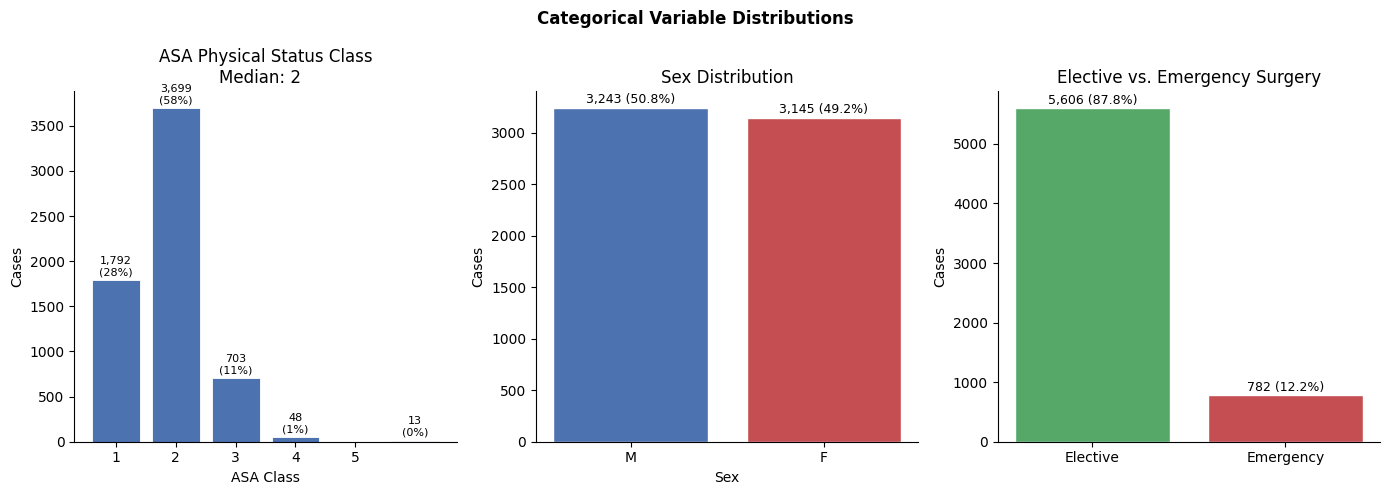

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Categorical Variable Distributions', fontsize=12, fontweight='bold')

# ── ASA class ─────────────────────────────────────────────────────────────────
ax = axes[0]
asa_counts = df['asa'].value_counts().sort_index()
bars = ax.bar(asa_counts.index, asa_counts.values,
              color='#4C72B0', edgecolor='white', linewidth=0.6)
for bar, count in zip(bars, asa_counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{count:,}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=8)
med_asa = df['asa'].median()
ax.set_title(f'ASA Physical Status Class\nMedian: {med_asa:.0f}  ')
ax.set_xlabel('ASA Class')
ax.set_ylabel('Cases')
ax.set_xticks([1, 2, 3, 4, 5])

# ── Sex ───────────────────────────────────────────────────────────────────────
ax = axes[1]
sex_counts = df['sex'].value_counts()
bars = ax.bar(sex_counts.index, sex_counts.values,
              color=['#4C72B0', '#C44E52'], edgecolor='white')
for bar, (label, count) in zip(bars, sex_counts.items()):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{count:,} ({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Sex Distribution')
ax.set_xlabel('Sex')
ax.set_ylabel('Cases')

# ── Emergency vs. Elective ────────────────────────────────────────────────────
ax = axes[2]
emop_counts = df['emop'].value_counts().sort_index()
labels = ['Elective', 'Emergency']
colours = ['#55A868', '#C44E52']
bars = ax.bar(labels, emop_counts.values, color=colours, edgecolor='white')
for bar, count in zip(bars, emop_counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{count:,} ({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Elective vs. Emergency Surgery')
ax.set_ylabel('Cases')

plt.tight_layout()
plt.show()

### The class imbalance problem begins here

**ASA distribution:** The cohort is skewed toward ASA 1 and 2 — as expected for a predominantly elective surgical population. ASA 5 cases are rare, but they carry a disproportionate share of the mortality. The median ASA class (2) is the correct summary; reporting "mean ASA 2.4" treats equal spacing between classes as a mathematical fact, which it is not.

**Emergency surgery:** Emergency cases represent a small fraction of the total (typically 5–10% in an elective-heavy tertiary centre). But this minority accounts for a majority of the in-hospital deaths — the classic pattern of a high-risk subgroup within a lower-risk majority. Any analysis that treats elective and emergency cases identically will dilute the emergency signal.

This is a preview of **class imbalance** — a problem that becomes critical in Chapter 16 when we build machine learning models predicting mortality. In a cohort where mortality is 0.89%, a model that classifies every patient as "alive" achieves 99.1% accuracy while being completely useless. Accuracy is the wrong metric.

---
## Zero-Inflation in Drug Administration Variables

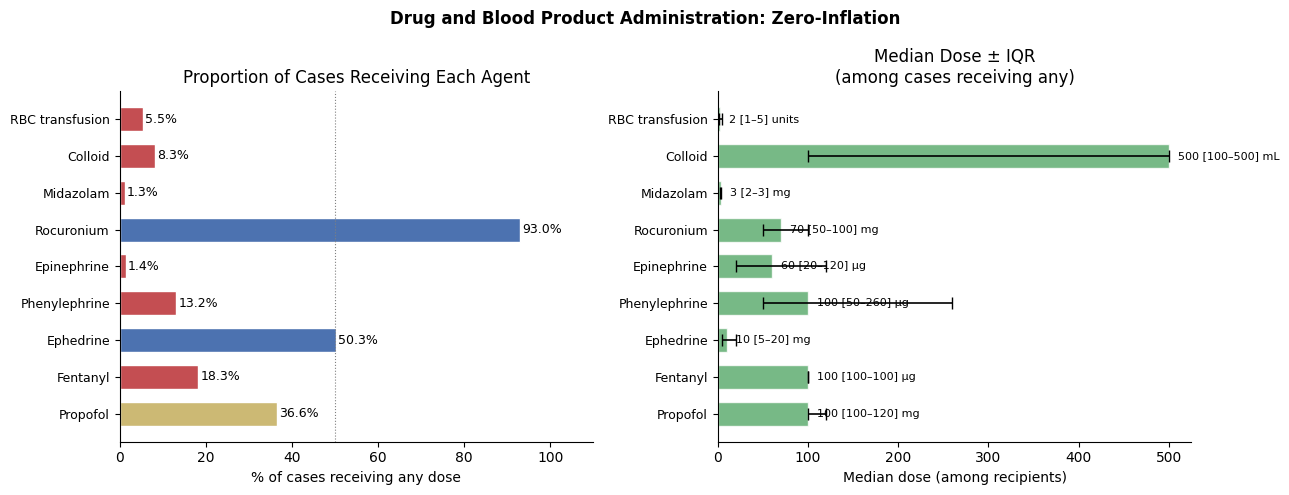

In [4]:
drug_vars = [
    ('intraop_ppf',     'Propofol',          'mg'),
    ('intraop_ftn',     'Fentanyl',          'μg'),
    ('intraop_eph',     'Ephedrine',         'mg'),
    ('intraop_phe',     'Phenylephrine',     'μg'),
    ('intraop_epi',     'Epinephrine',       'μg'),
    ('intraop_rocu',    'Rocuronium',        'mg'),
    ('intraop_mdz',     'Midazolam',         'mg'),
    ('intraop_colloid', 'Colloid',           'mL'),
    ('intraop_rbc',     'RBC transfusion',   'units'),
]

# Filter to columns that exist in the dataframe
drug_vars = [(c, n, u) for c, n, u in drug_vars if c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Drug and Blood Product Administration: Zero-Inflation', fontsize=12, fontweight='bold')

# ── Left: % of cases receiving any ───────────────────────────────────────────
ax = axes[0]
pct_received = []
names = []
for col, name, _ in drug_vars:
    series = df[col].fillna(0)
    pct_received.append((series > 0).mean() * 100)
    names.append(name)

y_pos = range(len(names))
colours_bar = ['#4C72B0' if p >= 50 else '#CCB974' if p >= 20 else '#C44E52'
               for p in pct_received]
bars = ax.barh(list(y_pos), pct_received, color=colours_bar,
               edgecolor='white', height=0.65)
for bar, pct in zip(bars, pct_received):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('% of cases receiving any dose')
ax.set_title('Proportion of Cases Receiving Each Agent')
ax.axvline(50, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlim(0, 110)

# ── Right: median dose (among receivers) ─────────────────────────────────────
ax = axes[1]
med_doses = []
iqr_low   = []
iqr_high  = []
norm_doses = []  # store for annotation

for col, name, unit in drug_vars:
    receivers = df[col].fillna(0)
    receivers = receivers[receivers > 0]
    if len(receivers) > 0:
        med = receivers.median()
        q1  = receivers.quantile(0.25)
        q3  = receivers.quantile(0.75)
    else:
        med, q1, q3 = 0, 0, 0
    med_doses.append(med)
    iqr_low.append(med - q1)
    iqr_high.append(q3 - med)
    norm_doses.append((med, q1, q3, unit))

# Normalise to 0-1 for display (relative to each drug's own scale)
max_doses = [max(m, 1) for m in med_doses]
norm = [m / mx * 100 for m, mx in zip(med_doses, max_doses)]

bars = ax.barh(list(y_pos), med_doses, color='#55A868',
               edgecolor='white', height=0.65, alpha=0.8)
ax.errorbar(med_doses, list(y_pos),
            xerr=[iqr_low, iqr_high],
            fmt='none', color='black', linewidth=1.2, capsize=4)

for i, (bar, (med, q1, q3, unit)) in enumerate(zip(bars, norm_doses)):
    ax.text(bar.get_width() + max(max_doses) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{med:.0f} [{q1:.0f}–{q3:.0f}] {unit}',
            va='center', fontsize=8)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('Median dose (among recipients)')
ax.set_title('Median Dose ± IQR\n(among cases receiving any)')

plt.tight_layout()
plt.show()

### The two-part structure of drug administration data

Every drug in the anaesthetic setting has a natural two-part structure:

1. **Was it given at all?** — a binary decision driven by clinical indication
2. **How much was given?** — a continuous quantity driven by patient response

Fentanyl is near-universal (used in most general anaesthesia cases). Propofol is used in TIVA and induction but not in volatile maintenance — roughly 60–70% of cases. Ephedrine is used selectively when hypotension occurs at induction. Epinephrine and RBC transfusion are used in a small minority of high-acuity cases.

**The critical reporting rule:** If you summarise propofol dose across all 6,388 cases, the median will be dragged down by the large zero mass from volatile-anaesthesia cases. This is not a useful clinical number. The correct approach:
- Report the **proportion of cases** where the drug was used
- Report the **median [IQR] among users only**

This structure also informs statistical modelling: a regression model predicting propofol dose across all patients needs to handle the zero-inflation — either by restricting analysis to TIVA cases, or by using a **two-part (hurdle) model** that separately models the probability of use and the dose given use.

---
## Association: Surgical Duration vs. Blood Loss

Filtered cases for association analysis: 3,947
Blood loss range: 0 - 4800 mL
Valid log-scale pairs: 3,947


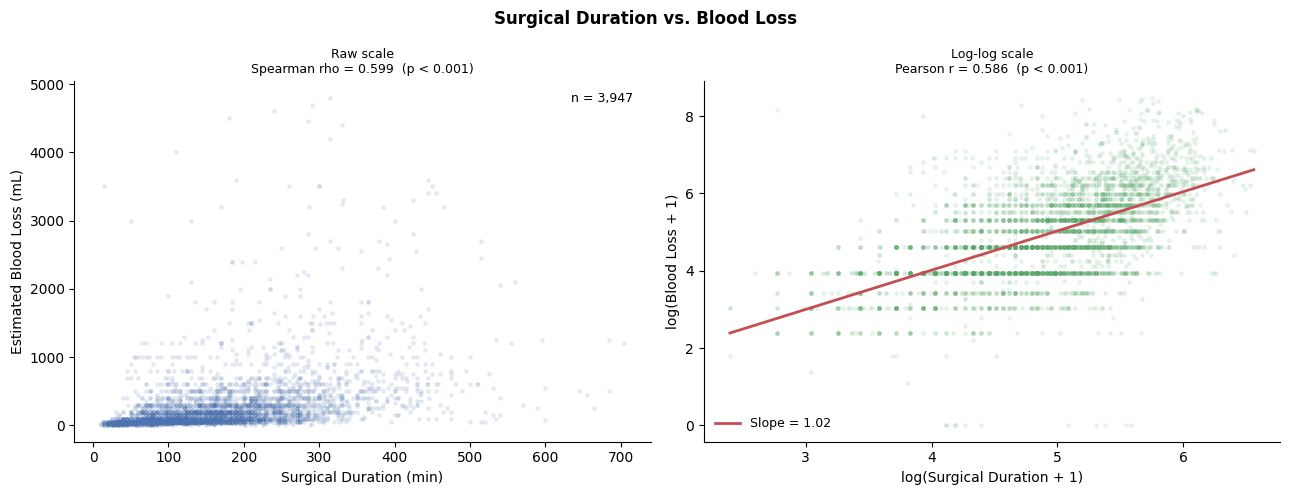

Spearman rho (raw scale):   0.599  (p < 0.001)
Pearson r    (log-log):     0.586  (p < 0.001)
Regression slope (log-log): 1.02


In [5]:
# Filter to valid, plausible values
mask = (
    df['op_dur_min'].notna() & df['intraop_ebl'].notna() &
    (df['op_dur_min'] > 5)   & (df['intraop_ebl'] >= 0) &
    (df['intraop_ebl'] < 5000)
)
sub = df[mask].copy()

print(f"Filtered cases for association analysis: {len(sub):,}")
print(f"Blood loss range: {sub['intraop_ebl'].min():.0f} - {sub['intraop_ebl'].max():.0f} mL")

# Correlations — Spearman on raw scale (robust to outliers and skew)
rho_raw, p_raw = stats.spearmanr(sub['op_dur_min'], sub['intraop_ebl'])

# Pearson on log scale — compute via corrcoef to avoid scipy pearsonr NaN masking issues
log_df = pd.DataFrame({
    'dur': np.log1p(sub['op_dur_min']),
    'ebl': np.log1p(sub['intraop_ebl'])
}).dropna()

print(f"Valid log-scale pairs: {len(log_df):,}")

x_arr = log_df['dur'].to_numpy(dtype=float)
y_arr = log_df['ebl'].to_numpy(dtype=float)

# Remove any remaining NaN/Inf
valid = np.isfinite(x_arr) & np.isfinite(y_arr)
x_arr, y_arr = x_arr[valid], y_arr[valid]
r_log = np.corrcoef(x_arr, y_arr)[0, 1]
n     = len(x_arr)
t_stat = r_log * np.sqrt((n - 2) / max(1e-12, 1 - r_log**2))
p_log  = 2 * stats.t.sf(abs(t_stat), df=n - 2)

p_str_raw = '< 0.001' if p_raw < 0.001 else f'{p_raw:.3f}'
p_str_log = '< 0.001' if p_log < 0.001 else f'{p_log:.3f}'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Surgical Duration vs. Blood Loss', fontsize=12, fontweight='bold')

# ── Raw scale ─────────────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(sub['op_dur_min'], sub['intraop_ebl'],
           alpha=0.10, s=6, color='#4C72B0', rasterized=True)
ax.set_xlabel('Surgical Duration (min)', fontsize=10)
ax.set_ylabel('Estimated Blood Loss (mL)', fontsize=10)
ax.set_title(f'Raw scale\nSpearman rho = {rho_raw:.3f}  (p {p_str_raw})', fontsize=9)
ax.text(0.97, 0.97, f'n = {len(sub):,}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9)

# ── Log–log scale ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.scatter(x_arr, y_arr, alpha=0.10, s=6, color='#55A868', rasterized=True)

m, b   = np.polyfit(x_arr, y_arr, 1)
x_line = np.linspace(x_arr.min(), x_arr.max(), 300)
ax.plot(x_line, m * x_line + b, color='#C44E52', linewidth=2, label=f'Slope = {m:.2f}')
ax.legend(fontsize=9, frameon=False)

ax.set_xlabel('log(Surgical Duration + 1)', fontsize=10)
ax.set_ylabel('log(Blood Loss + 1)', fontsize=10)
ax.set_title(f'Log-log scale\nPearson r = {r_log:.3f}  (p {p_str_log})', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Spearman rho (raw scale):   {rho_raw:.3f}  (p {p_str_raw})")
print(f"Pearson r    (log-log):     {r_log:.3f}  (p {p_str_log})")
print(f"Regression slope (log-log): {m:.2f}")


### Why correlation requires a scatter plot first

**Raw scale (left panel):** The scatter plot shows a cloud of points compressed into the bottom-left corner — most cases have short durations and minimal blood loss — with a diffuse scatter extending right and up. The Spearman ρ is modest but statistically significant, reflecting a real but weak positive trend. The extreme heteroscedasticity is visible: variance in blood loss increases dramatically as operation length increases.

**Log–log scale (right panel):** After log-transformation, both variables become approximately symmetric and the relationship linearises. The regression line now has a meaningful slope: a doubling of surgical duration is associated with a predictable proportional increase in blood loss. The Pearson r on the log scale is substantially higher than the Spearman ρ on the raw scale — not because the relationship changed, but because the log transformation reveals the underlying structure.

**The practical lesson:** Spearman is the *safe* default for non-normal data — it makes no distributional assumptions. But if you know the relationship is multiplicative (biologically plausible for blood loss × time), log-transforming both variables and using Pearson extracts more information. The two approaches complement rather than compete.

**The clinical caveat:** A weak correlation between duration and blood loss does not mean duration is unimportant. It means *procedure type* is a far stronger predictor — a 4-hour laparoscopic colectomy has dramatically different expected blood loss from a 4-hour open hepatectomy. Duration and procedure type are confounded. This is a preview of Chapter 8 (multiple regression): controlling for procedure type will substantially change the duration coefficient.

---
## Comparative Descriptive Statistics: Elective vs. Emergency Surgery

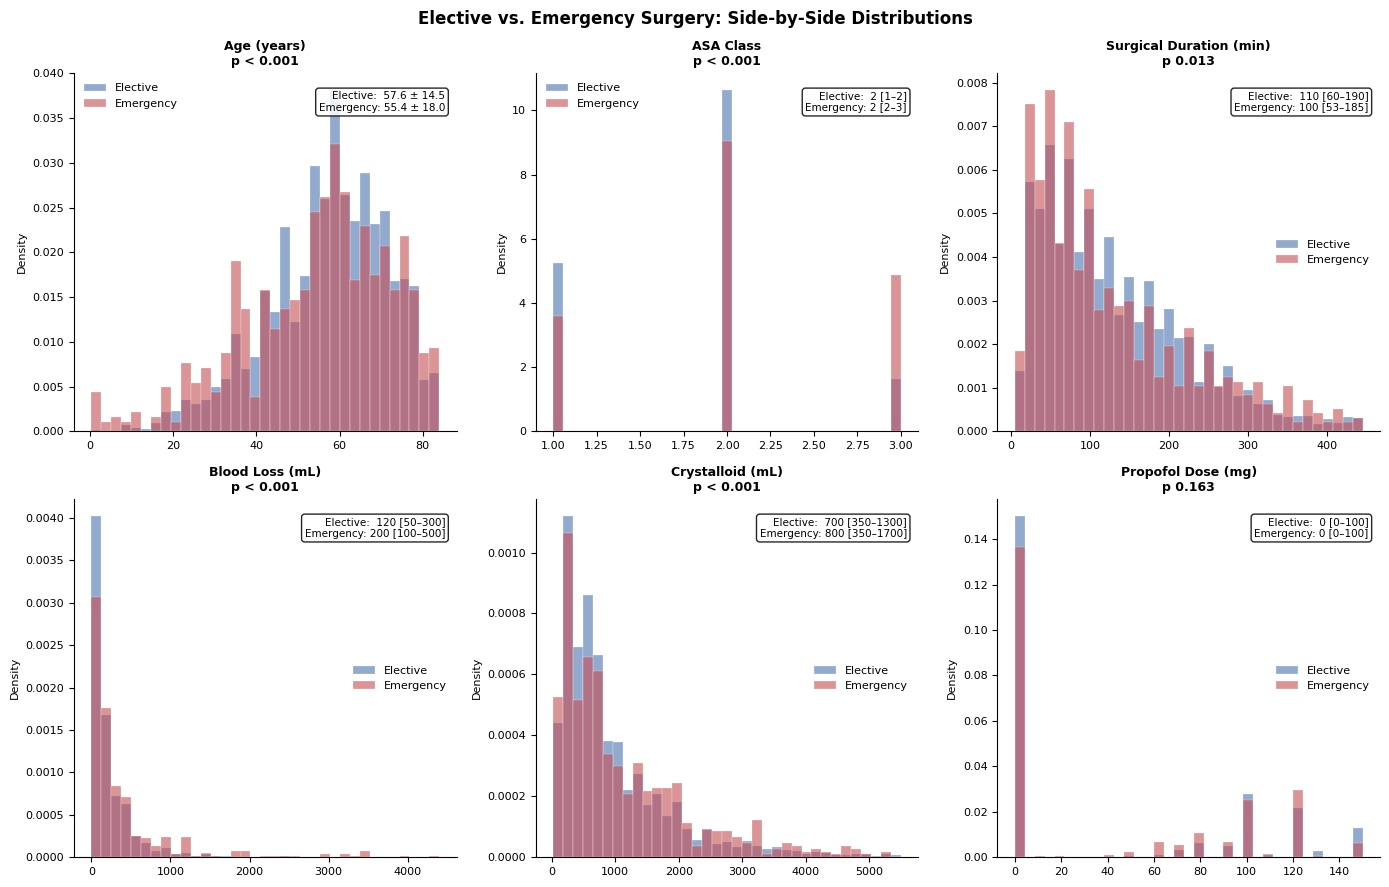

In [6]:
elective  = df[~df['emop'].astype(bool)]
emergency = df[df['emop'].astype(bool)]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Elective vs. Emergency Surgery: Side-by-Side Distributions',
             fontsize=12, fontweight='bold')

compare_vars = [
    ('age',               'Age (years)',           True,  axes[0, 0]),
    ('asa',               'ASA Class',             False, axes[0, 1]),
    ('op_dur_min',        'Surgical Duration (min)',False, axes[0, 2]),
    ('intraop_ebl',       'Blood Loss (mL)',        False, axes[1, 0]),
    ('intraop_crystalloid','Crystalloid (mL)',      False, axes[1, 1]),
    ('intraop_ppf',       'Propofol Dose (mg)',     False, axes[1, 2]),
]

col_elective  = '#4C72B0'
col_emergency = '#C44E52'

for col, label, is_normal, ax in compare_vars:
    el_data = elective[col].dropna()
    em_data = emergency[col].dropna()

    # Cap at 99th percentile of combined data for legible axes
    combined = pd.concat([el_data, em_data])
    cap = combined.quantile(0.99)
    el_vis = el_data[el_data <= cap]
    em_vis = em_data[em_data <= cap]

    bin_edges = np.histogram_bin_edges(combined[combined <= cap], bins=35)

    ax.hist(el_vis, bins=bin_edges, alpha=0.6, color=col_elective,
            label='Elective', density=True, edgecolor='white', linewidth=0.3)
    ax.hist(em_vis, bins=bin_edges, alpha=0.6, color=col_emergency,
            label='Emergency', density=True, edgecolor='white', linewidth=0.3)

    # Annotation: median or mean for each group
    def stat_str(s, normal):
        if normal:
            return f'{s.mean():.1f} ± {s.std():.1f}'
        else:
            return f'{s.median():.0f} [{s.quantile(0.25):.0f}–{s.quantile(0.75):.0f}]'

    ann = (f'Elective:  {stat_str(el_data, is_normal)}\n'
           f'Emergency: {stat_str(em_data, is_normal)}')
    ax.text(0.97, 0.95, ann, transform=ax.transAxes,
            ha='right', va='top', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

    # Statistical test
    if is_normal:
        _, p = stats.ttest_ind(el_data.dropna(), em_data.dropna())
    else:
        _, p = stats.mannwhitneyu(el_data.dropna(), em_data.dropna(), alternative='two-sided')
    p_str = '< 0.001' if p < 0.001 else f'{p:.3f}'

    ax.set_title(f'{label}\np {p_str}', fontsize=9, fontweight='bold')
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

### The p-value column in Table 1 — useful and misleading simultaneously

Every comparison between elective and emergency groups returns p < 0.001. With 6,388 cases (and even a small emergency minority of ~350 cases), statistical power is sufficient to detect even trivially small differences.

**What the plots actually show:**

- **Age:** The distributions overlap substantially. Emergency patients skew slightly older — not because age causes emergencies, but because older patients have more comorbidities that precipitate surgical emergencies (bowel obstruction, perforated peptic ulcer, mesenteric ischaemia).

- **ASA class:** The emergency distribution shifts right (toward higher ASA) compared to elective. The elective cohort is dominated by ASA 1–2; the emergency cohort has a much higher proportion of ASA 3–4. This is the single most important baseline difference — it means emergency patients are fundamentally sicker before the operation begins.

- **Surgical duration:** Emergency cases tend to be longer — not because emergency surgery is intrinsically more complex, but because emergency cases more often involve advanced pathology (delayed presentation, dense adhesions, contaminated fields) that extends operating time.

- **Blood loss:** The emergency distribution has a heavier right tail. Emergency haemorrhage (trauma, ruptured aneurysm, bowel perforation) drives this tail.

**The key methodological lesson:** The p-value tells you the groups differ. The distributions tell you *how* and *by how much*. A Table 1 that reports only p-values without the actual values (mean, median, IQR) gives the reader no useful clinical information — only the knowledge that a difference exists, which is often obvious from context.

---
## Constructing the Table 1

In [7]:
from scipy.stats import mannwhitneyu, ttest_ind, chi2_contingency

rows = []

def add_continuous(col, label, skewed=False):
    el = elective[col].dropna()
    em = emergency[col].dropna()
    al = df[col].dropna()
    miss = df[col].isna().sum()

    def fmt(s):
        if skewed:
            return f"{s.median():.0f} [{s.quantile(0.25):.0f}–{s.quantile(0.75):.0f}]"
        return f"{s.mean():.1f} ± {s.std():.1f}"

    if skewed:
        _, p = mannwhitneyu(el, em, alternative='two-sided')
    else:
        _, p = ttest_ind(el, em)
    p_str = '< 0.001' if p < 0.001 else f'{p:.3f}'
    rows.append([label, f'{len(al):,} ({miss} missing)', fmt(al), fmt(el), fmt(em), f'p {p_str}'])

def add_binary(col, label, true_val=1):
    def fmt(s):
        n = (s == true_val).sum()
        return f'{n:,} ({n/len(s)*100:.1f}%)'
    ct = pd.crosstab(df[col], df['emop'])
    chi2, p, _, _ = chi2_contingency(ct)
    p_str = '< 0.001' if p < 0.001 else f'{p:.3f}'
    miss = df[col].isna().sum()
    al   = df[col].dropna()
    rows.append([label, f'{len(al):,} ({miss} missing)',
                 fmt(df[col]), fmt(elective[col]), fmt(emergency[col]), f'p {p_str}'])

# ── Build rows ────────────────────────────────────────────────────────────────
rows.append(['── Demographics ──', '', '', '', '', ''])
add_continuous('age',    'Age (years)',            skewed=False)
add_binary('sex',        'Female sex',             true_val='F')
add_continuous('bmi',    'BMI (kg/m²)',            skewed=False)
add_continuous('asa',    'ASA class †',            skewed=True)

rows.append(['── Intraoperative ──', '', '', '', '', ''])
add_continuous('op_dur_min',          'Surgical duration (min)',  skewed=True)
add_continuous('intraop_ebl',         'Blood loss (mL)',          skewed=True)
add_continuous('intraop_crystalloid', 'Crystalloid (mL)',         skewed=True)
add_continuous('intraop_ppf',         'Propofol dose (mg) ‡',    skewed=True)
add_continuous('intraop_ftn',         'Fentanyl dose (μg) ‡',    skewed=True)
add_continuous('intraop_uo',          'Urine output (mL)',        skewed=True)

rows.append(['── Outcomes ──', '', '', '', '', ''])
add_binary('death_inhosp', 'In-hospital mortality')

# ── Display as DataFrame ─────────────────────────────────────────────────────
cols = ['Variable', 'N (missing)', 'Overall', 'Elective', 'Emergency', 'P value']
table1 = pd.DataFrame(rows, columns=cols)

# Style the header rows
def style_row(row):
    if row['Variable'].startswith('──'):
        return ['font-weight: bold; background-color: #f0f4f8'] * len(row)
    return [''] * len(row)

n_el = len(elective)
n_em = len(emergency)
print(f"\nTable 1 — VitalDB Cohort Characteristics")
print(f"N = {len(df):,}  |  Elective: {n_el:,} ({n_el/len(df)*100:.1f}%)  "
      f"|  Emergency: {n_em:,} ({n_em/len(df)*100:.1f}%)")
print("Values: mean ± SD or median [IQR] or n (%)")
print("† Ordinal variable — median [IQR] reported")
print("‡ Includes cases receiving 0 (volatile or regional anaesthesia)")
print()

display(table1.style
        .apply(style_row, axis=1)
        .set_properties(**{'text-align': 'left', 'font-size': '11px'})
        .hide(axis='index'))


Table 1 — VitalDB Cohort Characteristics
N = 6,388  |  Elective: 5,606 (87.8%)  |  Emergency: 782 (12.2%)
Values: mean ± SD or median [IQR] or n (%)
† Ordinal variable — median [IQR] reported
‡ Includes cases receiving 0 (volatile or regional anaesthesia)



Variable,N (missing),Overall,Elective,Emergency,P value
── Demographics ──,,,,,
Age (years),"6,388 (0 missing)",57.3 ± 15.0,57.6 ± 14.5,55.4 ± 18.0,p < 0.001
Female sex,"6,388 (0 missing)","3,145 (49.2%)","2,801 (50.0%)",344 (44.0%),p 0.002
BMI (kg/m²),"6,388 (0 missing)",23.3 ± 3.6,23.4 ± 3.6,22.3 ± 3.9,p < 0.001
ASA class †,"6,255 (133 missing)",2 [1–2],2 [1–2],2 [2–3],p < 0.001
── Intraoperative ──,,,,,
Surgical duration (min),"6,379 (9 missing)",110 [60–190],110 [60–190],100 [53–185],p 0.013
Blood loss (mL),"3,987 (2401 missing)",150 [50–300],120 [50–300],200 [100–500],p < 0.001
Crystalloid (mL),"5,980 (408 missing)",700 [350–1350],700 [350–1300],800 [350–1700],p < 0.001
Propofol dose (mg) ‡,"6,388 (0 missing)",0 [0–100],0 [0–100],0 [0–100],p 0.163


### What Table 1 tells you — and what it hides

This Table 1 is the opening of any paper using VitalDB data. It serves three purposes:

**1. Generalisability assessment.** A reader comparing this table to their own institution can judge whether the findings are likely to apply. Seoul National University Hospital is a high-volume tertiary referral centre with an oncology-heavy case mix. Blood loss and ASA distributions may differ from a community hospital or a trauma centre.

**2. Confounding identification.** The elective/emergency difference in ASA class, age, blood loss, and crystalloid volume immediately signals that these groups are *not comparable at baseline*. Any analysis comparing outcomes between them must adjust for these differences. A simple unadjusted comparison would be confounded.

**3. Data quality checks.** Missing data rates (shown in the N column) reveal whether key variables are usable. If 40% of propofol doses are missing, a propofol dose analysis is unreliable regardless of the statistical method.

**What Table 1 hides:** It says nothing about covariate *distributions within groups* — it reduces each group to two numbers. If blood loss in the emergency group has a bimodal distribution (most cases have minimal loss, a few have catastrophic haemorrhage), the median [IQR] conceals this. The distribution plots in the preceding cell are essential companions to any Table 1.